In [178]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from wordcloud import WordCloud
from collections import Counter
import re
from textblob import TextBlob
import tensorflow as tf

In [179]:
image_path = './train/radiology/images'
caption = './train/radiology/captions.txt'

In [180]:
df = pd.read_table(caption, header=None, names=['image_name', 'caption'])
df

,image_name,caption
0,ROCO_00002,Computed tomography scan in axial view showin...
1,ROCO_00003,Bacterial contamination occurred after comple...
2,ROCO_00004,The patient had residual paralysis of the han...
3,ROCO_00005,Panoramic radiograph after immediate loading.
4,ROCO_00007,Plain abdomen x-ray: Multiple air levels at t...
...,...,...
65445,ROCO_81819,Initial CT abdomen with contrast showing a di...
65446,ROCO_81820,44-year-old male patient after surgical amput...
65447,ROCO_81821,Primary pulmonary tuberculosis in 18-year-old...
65448,ROCO_81822,"MRI brain with gadolinium, coronal view, show..."


In [181]:
dlink_url = './train/radiology/dlinks.txt'
dlink = pd.read_table(dlink_url, header=None, names=['image_id', 'dlink', 'image'])
dlink

,image_id,dlink,image
0,ROCO_00002,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,AMHSR-4-14-g002.jpg
1,ROCO_00003,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,IJD2009-150251.001.jpg
2,ROCO_00004,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,11999_2007_30_Fig6_HTML.jpg
3,ROCO_00005,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,IJD2013-683423.005.jpg
4,ROCO_00007,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,amjcaserep-17-301-g001.jpg
...,...,...,...
65445,ROCO_81819,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,CRIM.HEMATOLOGY2012-490438.001.jpg
65446,ROCO_81820,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,rb-50-03-0190-g13.jpg
65447,ROCO_81821,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,kjr-11-612-g001.jpg
65448,ROCO_81822,wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...,AJNS-7-151-g002.jpg


In [182]:
# Define paths for each split (train, test, validation) and categories (radiology, non-radiology)
base_dir = '.'

# Define the splits and categories
splits = ['train', 'test', 'validation']
categories = ['radiology', 'non-radiology']

# Initialize an empty list to store the data
data = []

# Loop through each split and category to read captions
for split in splits:
    for category in categories:
        # Define paths for images and captions.txt
        category_dir = os.path.join(base_dir, split, category)
        captions_file = os.path.join(category_dir, 'captions.txt')
        
        # Read the captions file if it exists
        if os.path.exists(captions_file):
            with open(captions_file, 'r', encoding='utf-8', errors='ignore') as file:
                # Read each line in the captions file
                for line in file:
                    image_id = line[:12]    # Assuming the first 12 characters are the image ID
                    caption = line[12:].strip()  # The rest of the line is the caption text
                    label = category  # Set label as 'radiology' or 'non-radiology'
                    
                    # Append to data list with image ID, caption, label, and split type
                    data.append([image_id, caption, label, split])

# Create a DataFrame with the collected data
df = pd.DataFrame(data, columns=['image_id', 'caption', 'label', 'split'])

# Display the first few rows of the DataFrame to verify
df


,image_id,caption,label,split
0,ROCO_00002\t,Computed tomography scan in axial view showing...,radiology,train
1,ROCO_00003\t,Bacterial contamination occurred after complet...,radiology,train
2,ROCO_00004\t,The patient had residual paralysis of the hand...,radiology,train
3,ROCO_00005\t,Panoramic radiograph after immediate loading.,radiology,train
4,ROCO_00007\t,Plain abdomen x-ray: Multiple air levels at th...,radiology,train
...,...,...,...,...
87922,ROCO_87894\t,Scanning electron photomicrograph of blood cel...,non-radiology,validation
87923,ROCO_87904\t,SEM of Solenopsis elhawagryi sp. n. minor work...,non-radiology,validation
87924,ROCO_87918\t,Under visualization through the anterolateral ...,non-radiology,validation
87925,ROCO_87936\t,The endoscopic view demonstrated progressive d...,non-radiology,validation


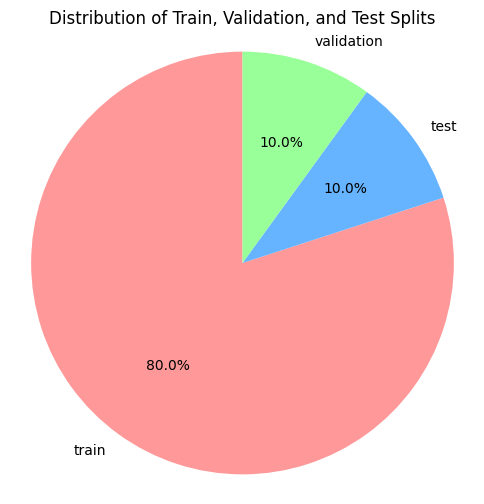

In [183]:
split_counts = df['split'].value_counts()

# Plot a pie chart
plt.figure(figsize=(6, 6))
plt.pie(split_counts, labels=split_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Distribution of Train, Validation, and Test Splits')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.
plt.show()

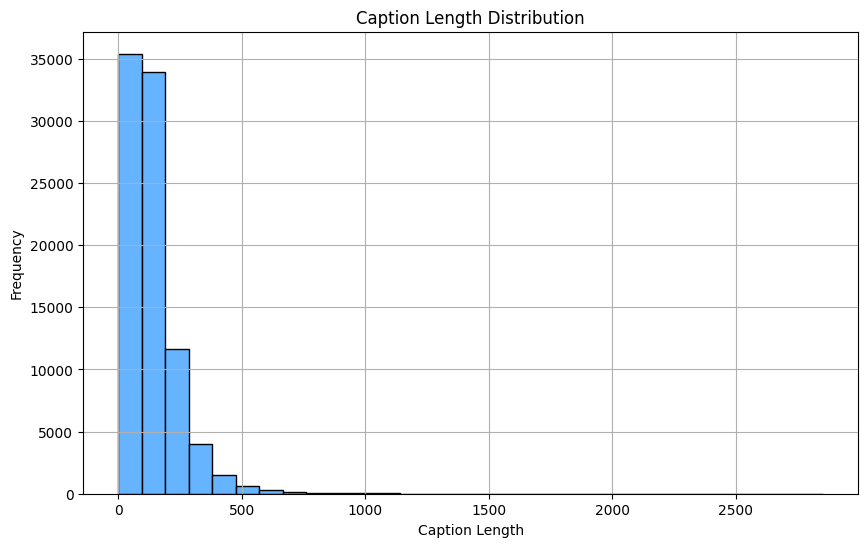

In [184]:
df['caption_length'] = df['caption'].apply(len)

# Plot a histogram of caption lengths
plt.figure(figsize=(10, 6))
plt.hist(df['caption_length'], bins=30, color='#66b3ff', edgecolor='black')
plt.title('Caption Length Distribution')
plt.xlabel('Caption Length')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

<Axes: xlabel='caption_length', ylabel='Count'>

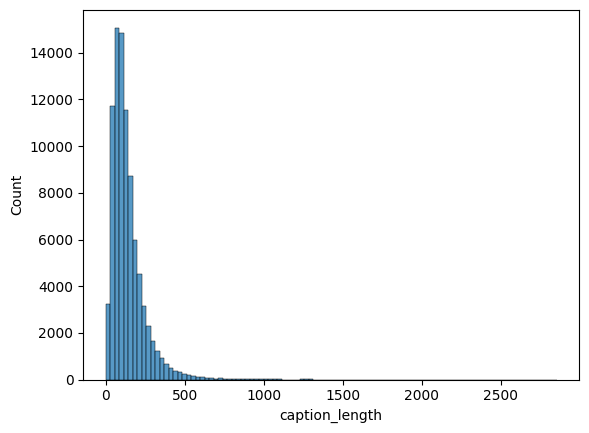

In [185]:
sns.histplot(df['caption_length'],bins=100)

In [186]:
dlink['description_length'] = dlink['dlink'].str.len()
print(dlink.head())

     image_id                                              dlink  \
0  ROCO_00002  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
1  ROCO_00003  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
2  ROCO_00004  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
3  ROCO_00005  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   
4  ROCO_00007  wget -r ftp://ftp.ncbi.nlm.nih.gov/pub/pmc/oa_...   

                         image  description_length  
0          AMHSR-4-14-g002.jpg                  93  
1       IJD2009-150251.001.jpg                  93  
2  11999_2007_30_Fig6_HTML.jpg                  93  
3       IJD2013-683423.005.jpg                  93  
4   amjcaserep-17-301-g001.jpg                  93  


In [187]:
dlink['description_length'].describe()

count    65450.000000
mean        92.995600
std          0.070871
min         91.000000
25%         93.000000
50%         93.000000
75%         93.000000
max         93.000000
Name: description_length, dtype: float64

In [188]:
image_files_list = os.listdir(image_path)

In [189]:
image_files_df = pd.DataFrame(image_files_list, columns=['image_file'])

In [190]:
image_files_df

,image_file
0,PMC5615809_12879_2017_2753_Fig1_HTML.jpg
1,PMC3052610_kjr-12-196-g005.jpg
2,PMC3298228_wjem-13-01-38w-f03.jpg
3,PMC3630350_kju-54-274-g001.jpg
4,PMC272934_1477-7819-1-22-1.jpg
...,...
65415,PMC5344664_abc-108-02-0173-g05.jpg
65416,PMC4573410_gr3.jpg
65417,PMC3467426_crt-44-215-g001.jpg
65418,PMC4826510_13019_2016_463_Fig2_HTML.jpg


In [191]:
df['index'] = df.index
image_files_df['index'] = image_files_df.index

# Merge based on the index column
merged_df = pd.merge(image_files_df, df, on='index', how='inner')

# Reorder columns to display image_file first
merged_df = merged_df[['image_file', 'caption']]

# Display the result (ensure both columns are properly aligned)
merged_df

,image_file,caption
0,PMC5615809_12879_2017_2753_Fig1_HTML.jpg,Computed tomography scan in axial view showing...
1,PMC3052610_kjr-12-196-g005.jpg,Bacterial contamination occurred after complet...
2,PMC3298228_wjem-13-01-38w-f03.jpg,The patient had residual paralysis of the hand...
3,PMC3630350_kju-54-274-g001.jpg,Panoramic radiograph after immediate loading.
4,PMC272934_1477-7819-1-22-1.jpg,Plain abdomen x-ray: Multiple air levels at th...
...,...,...
65415,PMC5344664_abc-108-02-0173-g05.jpg,T2 weighted image in coronal view revealing a ...
65416,PMC4573410_gr3.jpg,Portable frontal upright chest. The heart is n...
65417,PMC3467426_crt-44-215-g001.jpg,HCC nodule with a hypervascular character in r...
65418,PMC4826510_13019_2016_463_Fig2_HTML.jpg,An oblique axial image demonstrates widely pat...


In [192]:
list1 = []
if os.path.exists(image_path):
    for file in os.listdir(image_path):
        list1.append(file)
else:
    print(f"The path {image_path} does not exist.")
len(list1)

65420

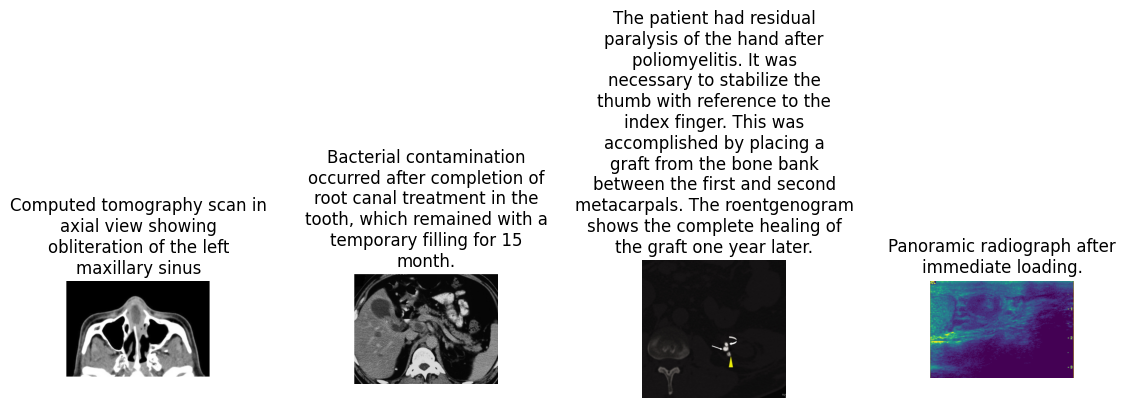

In [193]:
import textwrap

file_names1 = os.listdir(image_path)
wrap_width = 30

fig, axs = plt.subplots(1,4, figsize=(13, 15))

plt.subplots_adjust(wspace = 1,hspace=1)
axs = axs.flatten()
for i in range(4):
    file_path = os.path.join(image_path, list1[i])
    image = Image.open(file_path)
    caption = df["caption"][i]
    wrapped_caption = "\n".join(textwrap.wrap(caption, wrap_width))
    axs[i].imshow(image)
    axs[i].set_title(wrapped_caption)
    axs[i].axis('off')

plt.show()

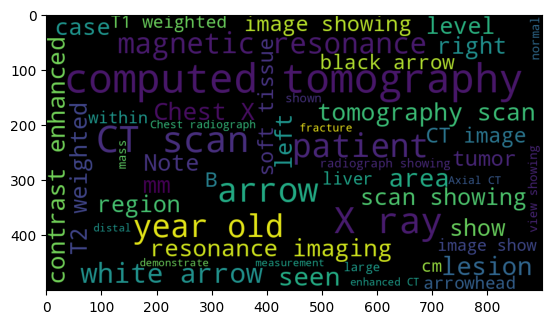

In [194]:
from wordcloud import WordCloud
caption_text=' '.join(df['caption'].astype(str))
wordcloud=WordCloud(width=900,height=500,max_words=50).generate(caption_text)
plt.imshow(wordcloud)

# IMAGE PREPROCESSING

In [195]:
img_path=os.path.join(image_path,image_files_list[53])
img_path

'./train/radiology/images/PMC4392537_SNI-6-40-g002.jpg'

In [196]:
import cv2
img=cv2.imread(img_path)
img

array([[[191, 191, 191],
        [179, 179, 179],
        [175, 175, 175],
        ...,
        [164, 164, 164],
        [173, 173, 173],
        [165, 165, 165]],

       [[180, 180, 180],
        [178, 178, 178],
        [195, 195, 195],
        ...,
        [157, 157, 157],
        [160, 160, 160],
        [155, 155, 155]],

       [[182, 182, 182],
        [180, 180, 180],
        [196, 196, 196],
        ...,
        [157, 157, 157],
        [154, 154, 154],
        [150, 150, 150]],

       ...,

       [[173, 173, 173],
        [174, 174, 174],
        [168, 168, 168],
        ...,
        [168, 168, 168],
        [155, 155, 155],
        [155, 155, 155]],

       [[175, 175, 175],
        [166, 166, 166],
        [166, 166, 166],
        ...,
        [172, 172, 172],
        [163, 163, 163],
        [166, 166, 166]],

       [[176, 176, 176],
        [162, 162, 162],
        [163, 163, 163],
        ...,
        [170, 170, 170],
        [171, 171, 171],
        [178, 178, 178]]

In [197]:
target_size=(230,230)
cv2.resize(img,target_size)

array([[[180, 180, 180],
        [196, 196, 196],
        [196, 196, 196],
        ...,
        [158, 158, 158],
        [159, 159, 159],
        [162, 162, 162]],

       [[190, 190, 190],
        [199, 199, 199],
        [170, 170, 170],
        ...,
        [163, 163, 163],
        [158, 158, 158],
        [158, 158, 158]],

       [[197, 197, 197],
        [171, 171, 171],
        [179, 179, 179],
        ...,
        [156, 156, 156],
        [153, 153, 153],
        [152, 152, 152]],

       ...,

       [[170, 170, 170],
        [169, 169, 169],
        [175, 175, 175],
        ...,
        [170, 170, 170],
        [164, 164, 164],
        [164, 164, 164]],

       [[174, 174, 174],
        [155, 155, 155],
        [172, 172, 172],
        ...,
        [156, 156, 156],
        [166, 166, 166],
        [155, 155, 155]],

       [[169, 169, 169],
        [174, 174, 174],
        [164, 164, 164],
        ...,
        [169, 169, 169],
        [174, 174, 174],
        [167, 167, 167]]

In [198]:
img_processed=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
img_processed

array([[191, 179, 175, ..., 164, 173, 165],
       [180, 178, 195, ..., 157, 160, 155],
       [182, 180, 196, ..., 157, 154, 150],
       ...,
       [173, 174, 168, ..., 168, 155, 155],
       [175, 166, 166, ..., 172, 163, 166],
       [176, 162, 163, ..., 170, 171, 178]], dtype=uint8)

In [199]:
img_normalised=img/255
img_normalised

array([[[0.74901961, 0.74901961, 0.74901961],
        [0.70196078, 0.70196078, 0.70196078],
        [0.68627451, 0.68627451, 0.68627451],
        ...,
        [0.64313725, 0.64313725, 0.64313725],
        [0.67843137, 0.67843137, 0.67843137],
        [0.64705882, 0.64705882, 0.64705882]],

       [[0.70588235, 0.70588235, 0.70588235],
        [0.69803922, 0.69803922, 0.69803922],
        [0.76470588, 0.76470588, 0.76470588],
        ...,
        [0.61568627, 0.61568627, 0.61568627],
        [0.62745098, 0.62745098, 0.62745098],
        [0.60784314, 0.60784314, 0.60784314]],

       [[0.71372549, 0.71372549, 0.71372549],
        [0.70588235, 0.70588235, 0.70588235],
        [0.76862745, 0.76862745, 0.76862745],
        ...,
        [0.61568627, 0.61568627, 0.61568627],
        [0.60392157, 0.60392157, 0.60392157],
        [0.58823529, 0.58823529, 0.58823529]],

       ...,

       [[0.67843137, 0.67843137, 0.67843137],
        [0.68235294, 0.68235294, 0.68235294],
        [0.65882353, 0

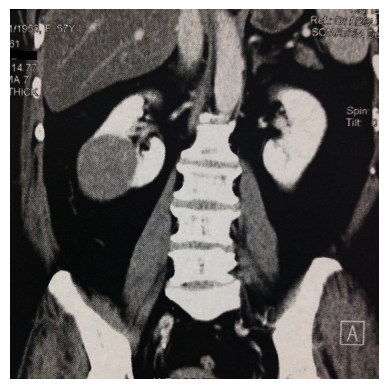

In [200]:
plt.imshow(img_normalized)
plt.axis('off')
plt.show()

In [201]:
# Optional: Apply histogram equalization and denoising
img_eq = cv2.equalizeHist(img_processed.squeeze())
print(f"Equalized Image (first 5 pixels): {img_eq[:5, :5]}")

img_denoised = cv2.GaussianBlur(img_eq, (5, 5), 0)
print(f"Denoised Image (first 5 pixels): {img_denoised[:5, :5]}")

Equalized Image (first 5 pixels): [[255 254 248 255 255]
 [254 253 255 255 255]
 [254 254 255 255 255]
 [255 255 255 255 253]
 [255 255 255 255 190]]
Denoised Image (first 5 pixels): [[254 254 254 254 254]
 [254 254 254 254 253]
 [254 254 254 253 249]
 [254 254 251 247 240]
 [252 249 242 234 229]]


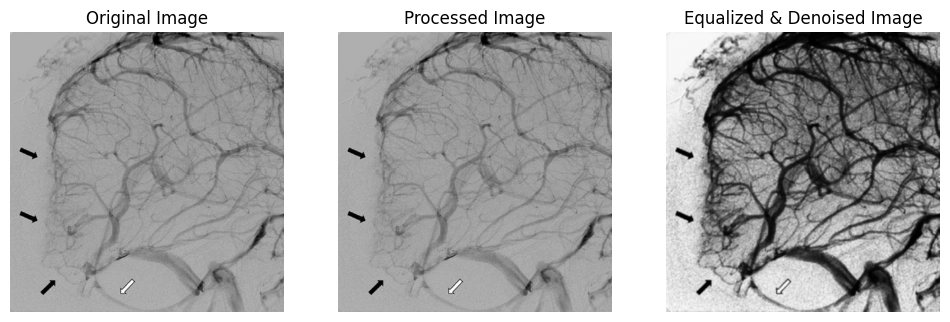

In [202]:
# Visualize the original, preprocessed, and denoised images

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
img_original = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Processed Image (Grayscale & Normalized)
plt.subplot(1, 3, 2)
plt.imshow(img_processed.squeeze(), cmap='gray')
plt.title('Processed Image')
plt.axis('off')

# Equalized and Denoised Image (Optional)
plt.subplot(1, 3, 3)
plt.imshow(img_denoised, cmap='gray')
plt.title('Equalized & Denoised Image')
plt.axis('off')

plt.show()


In [203]:
img=np.expand_dims(img,axis=0)

In [204]:
from tensorflow.keras.preprocessing import image as keras_image
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

img = keras_image.load_img(img_path)
img_array = keras_image.img_to_array(img) / 255.0

# Expand dimensions to create a batch of size 1
img_batch = np.expand_dims(img_array, axis=0)

# Create the augmented images generator
augmented_images = datagen.flow(img_batch)

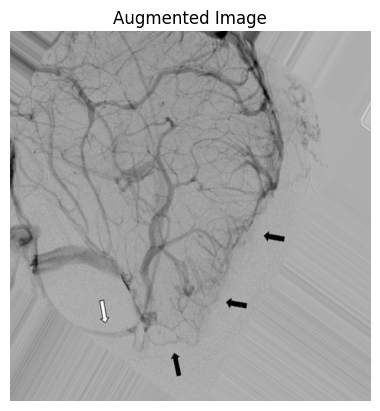

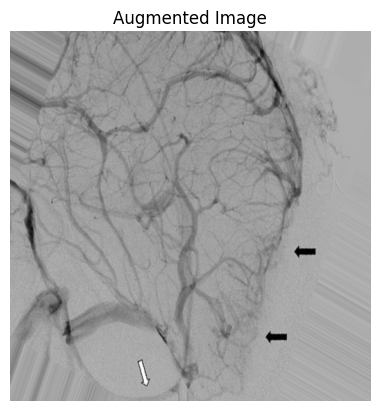

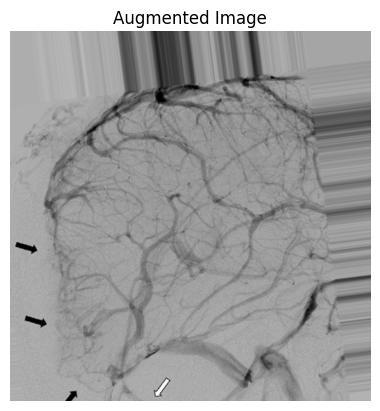

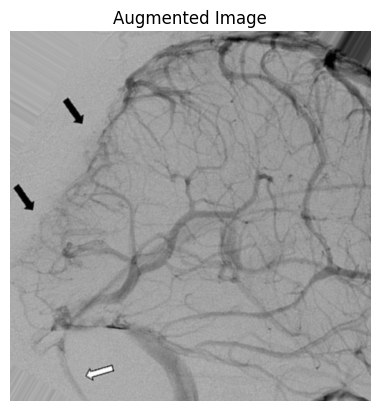

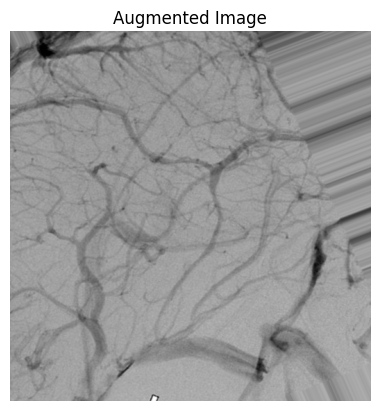

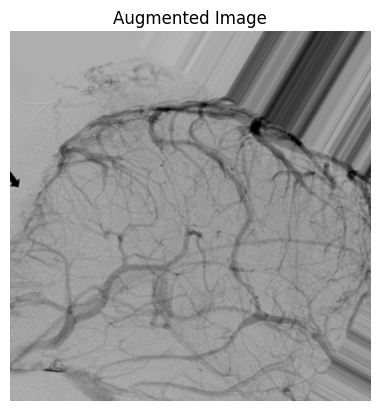

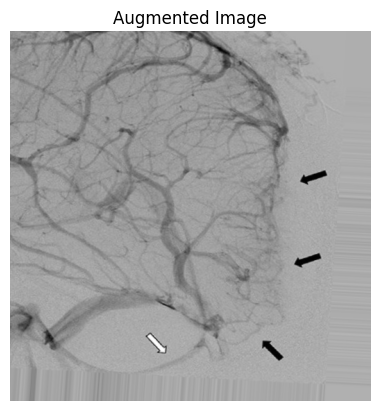

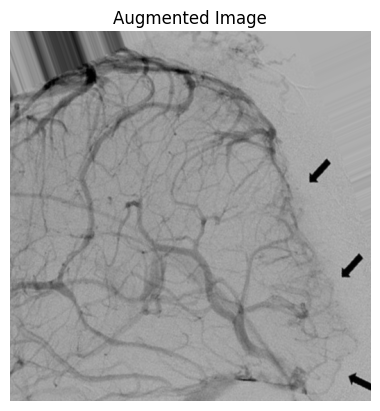

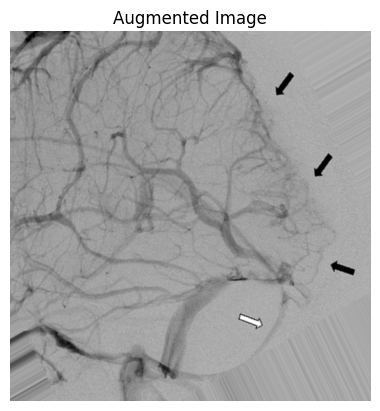

In [205]:
def show_image(image, title="Image"):
    plt.imshow(image)
    plt.axis('off')
    plt.title(title)
    plt.show()
for _ in range(9):  # Show 9 augmented images
    aug_img = next(augmented_images)[0]
    show_image(aug_img, title="Augmented Image")

# NATURAL LANGUAGE PROCESSING

In [206]:
df['caption']=df['caption'].str.lower()

In [207]:
df['caption'][500]

'a plain radiograph taken on arrival to the emergency department displaying the inferior dislocation of the hip.'

#### STOP WORDS

In [208]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words=set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/sharon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [209]:
def remove_stopwords(caption):

    words = word_tokenize(caption)

    stop_words = set(stopwords.words('english'))

    filtered_words = [word for word in words if word.lower() not in stop_words]
    
    # Join the filtered words back into a string
    return ' '.join(filtered_words)

df['caption'] = df['caption'].apply(remove_stopwords)


In [210]:
captions = " ".join(df['caption'])
print(captions[:1000])

computed tomography scan axial view showing obliteration left maxillary sinus bacterial contamination occurred completion root canal treatment tooth , remained temporary filling 15 month . patient residual paralysis hand poliomyelitis . necessary stabilize thumb reference index finger . accomplished placing graft bone bank first second metacarpals . roentgenogram shows complete healing graft one year later . panoramic radiograph immediate loading . plain abdomen x-ray : multiple air levels mid-abdomen ( arrows ) , radiopaque shadow , air diaphragm . 3-year-old child visual difficulties . axial flair image show supra-sellar lesion extending temporal lobes along optic tracts ( arrows ) moderate mass effect , compatible optic glioma . flair hyperintensity also noted left mesencephalon additional tumoral involvement showing subtrochanteric fracture porotic bone . post orthodontic treatment . root canal therapy done maxillary incisors two sequential thrombi distal segment obtuse marginal 2 

In [211]:
stop_words=set(stopwords.words('english'))
text_input=" ".join([word for word in captions.split() if word not in stop_words])

#### TOKENIZATION

In [212]:
from nltk.tokenize import sent_tokenize
from nltk.tokenize import wordpunct_tokenize

sent_input=sent_tokenize(text_input)
word_input=wordpunct_tokenize(text_input)


In [213]:
from nltk.tokenize import TreebankWordTokenizer
tokenizer=TreebankWordTokenizer()
tokenize_input=tokenizer.tokenize(text_input)

In [214]:
print(tokenize_input[:1000])

['computed', 'tomography', 'scan', 'axial', 'view', 'showing', 'obliteration', 'left', 'maxillary', 'sinus', 'bacterial', 'contamination', 'occurred', 'completion', 'root', 'canal', 'treatment', 'tooth', ',', 'remained', 'temporary', 'filling', '15', 'month', '.', 'patient', 'residual', 'paralysis', 'hand', 'poliomyelitis', '.', 'necessary', 'stabilize', 'thumb', 'reference', 'index', 'finger', '.', 'accomplished', 'placing', 'graft', 'bone', 'bank', 'first', 'second', 'metacarpals', '.', 'roentgenogram', 'shows', 'complete', 'healing', 'graft', 'one', 'year', 'later', '.', 'panoramic', 'radiograph', 'immediate', 'loading', '.', 'plain', 'abdomen', 'x-ray', ':', 'multiple', 'air', 'levels', 'mid-abdomen', '(', 'arrows', ')', ',', 'radiopaque', 'shadow', ',', 'air', 'diaphragm', '.', '3-year-old', 'child', 'visual', 'difficulties', '.', 'axial', 'flair', 'image', 'show', 'supra-sellar', 'lesion', 'extending', 'temporal', 'lobes', 'along', 'optic', 'tracts', '(', 'arrows', ')', 'moderate

#### STEMMING

In [215]:
df1=pd.read_table("./test/non-radiology/keywords.txt",header=None,names=['image_id','col1','reason','body_part','element','disease','col2','col3','col4','col5','col6'],sep="\t",on_bad_lines='skip')

In [216]:
df1

,image_id,col1,reason,body_part,element,disease,col2,col3,col4,col5,col6
0,ROCO_81827,NaN,demineralized,slurrygroup,enamel,pumouse,prophylaxi,electron,microscopy,magnification,original
1,ROCO_81853,NaN,incubation,skin,glycerol,allograft,NaN,NaN,NaN,NaN,NaN
2,ROCO_81857,NaN,jacobaeu,highlight,christian,han,figure,NaN,NaN,NaN,NaN
3,ROCO_81867,NaN,extension,colonoscopy,biopsy,tumor,adenocarcinoma,circumferential,rectosigmoid,type,NaN
4,ROCO_81884,NaN,photograph,right,superolateral,suprapatellar,aspiration,bursa,knee,injection,approach
...,...,...,...,...,...,...,...,...,...,...,...
356,ROCO_87876,NaN,aspect,palatal,image,arrow,defect,threedimensional,red,circumferential,bone
357,ROCO_87885,NaN,right,eye,valved,view,cadaver,intraoperative,rabbit,cannula,left
358,ROCO_87900,NaN,pelvi,purulent,drainage,NaN,NaN,NaN,NaN,NaN,NaN
359,ROCO_87903,NaN,canal,right,scan,pet,region,inguinal,anal,uptake,NaN


In [217]:
list1 = []
for i in df1['reason']:  # select 'reason' and 'element' columns
    list1.append(i)

for i in df1['element']:
    list1.append(i)

print(list1)

['demineralized', 'incubation', 'jacobaeu', 'extension', 'photograph', 'point', 'case', 'dentin', 'ball', 'rupture', 'oocyte', 'asymmetric', 'impression', 'image', 'vr', 'cystoid', 'implantation', 'surgery', 'bulb', 'wound', 'mas', 'pigmentation', 'comparison', 'opacity', 'anglia', 'achille', 'speciman', 'map', 'scrotal', 'clip', 'torsion', 'device', 'lateral', 'basal', 'body', 'body', 'case', 'fistula', 'ix', 'occipitocervical', 'plant', 'protuberance', 'reference', 'prototype', 'limb', 'repair', 'end', 'trocar', 'university', 'diagram', 'inflammatory', 'iwqi', 'transnasal', 'image', 'week', 'upper', 'ball', 'case', 'pattern', 'len', 'appliance', 'superior', 'bougie', 'positioning', 'stone', 'urinary', 'technique', 'terminal', 'body', 'wire', 'patient', 'wheel', 'dodziuk', 'thoracotomy', 'echocardiography', 'hnf4dna', 'barbicide', 'pattern', 'embedded', 'view', 'placement', 'extremity', 'position', 'taping', 'opg', 'fullthicknes', 'anterior', 'pain', 'abbott', 'intraoperative', 'tie',

In [218]:
from nltk.stem import PorterStemmer
ps = PorterStemmer()

for i in list1:
    if isinstance(i, str):  # Ensure the item is a string
        print(i, "......" + ps.stem(i))
    else:
        print(i, "...... Non-string value, skipping")

demineralized ......deminer
incubation ......incub
jacobaeu ......jacobaeu
extension ......extens
photograph ......photograph
point ......point
case ......case
dentin ......dentin
ball ......ball
rupture ......ruptur
oocyte ......oocyt
asymmetric ......asymmetr
impression ......impress
image ......imag
vr ......vr
cystoid ......cystoid
implantation ......implant
surgery ......surgeri
bulb ......bulb
wound ......wound
mas ......ma
pigmentation ......pigment
comparison ......comparison
opacity ......opac
anglia ......anglia
achille ......achil
speciman ......speciman
map ......map
scrotal ......scrotal
clip ......clip
torsion ......torsion
device ......devic
lateral ......later
basal ......basal
body ......bodi
body ......bodi
case ......case
fistula ......fistula
ix ......ix
occipitocervical ......occipitocerv
plant ......plant
protuberance ......protuber
reference ......refer
prototype ......prototyp
limb ......limb
repair ......repair
end ......end
trocar ......trocar
university .....

#### REGEXPSTEMMING

In [219]:
from nltk.stem import RegexpStemmer
reg_stemer=RegexpStemmer('ing$|e$|s$|able$')

for i in list1:
    if isinstance(i, str):  # Ensure the item is a string
        print(i, "......" + reg_stemer.stem(i))
    else:
        print(i, "...... Non-string value, skipping")

demineralized ......demineralized
incubation ......incubation
jacobaeu ......jacobaeu
extension ......extension
photograph ......photograph
point ......point
case ......cas
dentin ......dentin
ball ......ball
rupture ......ruptur
oocyte ......oocyt
asymmetric ......asymmetric
impression ......impression
image ......imag
vr ......vr
cystoid ......cystoid
implantation ......implantation
surgery ......surgery
bulb ......bulb
wound ......wound
mas ......ma
pigmentation ......pigmentation
comparison ......comparison
opacity ......opacity
anglia ......anglia
achille ......achill
speciman ......speciman
map ......map
scrotal ......scrotal
clip ......clip
torsion ......torsion
device ......devic
lateral ......lateral
basal ......basal
body ......body
body ......body
case ......cas
fistula ......fistula
ix ......ix
occipitocervical ......occipitocervical
plant ......plant
protuberance ......protuberanc
reference ......referenc
prototype ......prototyp
limb ......limb
repair ......repair
end ...

#### LEMMATIZATION

In [220]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/sharon/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [221]:
lemmatizer=WordNetLemmatizer()
lemmatizer.lemmatize('corpora')

'corpus'

In [222]:
lemmatizer.lemmatize(text_input[:5000],pos="n")

'computed tomography scan axial view showing obliteration left maxillary sinus bacterial contamination occurred completion root canal treatment tooth , remained temporary filling 15 month . patient residual paralysis hand poliomyelitis . necessary stabilize thumb reference index finger . accomplished placing graft bone bank first second metacarpals . roentgenogram shows complete healing graft one year later . panoramic radiograph immediate loading . plain abdomen x-ray : multiple air levels mid-abdomen ( arrows ) , radiopaque shadow , air diaphragm . 3-year-old child visual difficulties . axial flair image show supra-sellar lesion extending temporal lobes along optic tracts ( arrows ) moderate mass effect , compatible optic glioma . flair hyperintensity also noted left mesencephalon additional tumoral involvement showing subtrochanteric fracture porotic bone . post orthodontic treatment . root canal therapy done maxillary incisors two sequential thrombi distal segment obtuse marginal 2

#### NAMED ENTITY RECOGNITION

In [223]:
nltk.download("maxent_ne_chunker")
nltk.download("words")

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /home/sharon/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /home/sharon/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [225]:
new_df = df.sample(n=100, random_state=42)

In [228]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 3.0 MB/s eta 0:00:000:00:01m eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [235]:
import spacy
from spacy import displacy
nlp=spacy.load("en_core_web_sm")
doc=nlp(text_input[:10000])
displacy.render(doc,style="ent",jupyter=True)

In [240]:
ner_caption = []

for caption in new_df['caption']:
    tokens = word_tokenize(caption)  # Tokenize the caption
    tags = nltk.pos_tag(tokens)      # POS tagging is needed for NER
    entities = nltk.ne_chunk(tags)  # Get NER tags
    ner_caption.append(entities)

In [241]:
ner_caption

[Tree('S', [('angiogram', 'JJ'), ('contrast', 'NN'), ('material', 'NN'), ('injection', 'NN'), ('shows', 'VBZ'), ('glue', 'JJ'), ('cast', 'NN'), ('(', '('), ('arrows', 'NNS'), (')', ')')]),
 Tree('S', [('abdominal', 'JJ'), ('ct', 'NN'), ('shows', 'NNS'), ('localized', 'VBD'), ('inhomogeneous', 'JJ'), ('enhanced', 'VBD'), ('submucosal', 'JJ'), ('mass', 'NN'), ('approximately', 'RB'), ('3', 'CD'), ('cm', 'NNS'), ('size', 'NN'), ('greater', 'JJR'), ('curvature', 'NN'), ('gastric', 'NN'), ('midbody', 'NN'), ('(', '('), ('arrow', 'NN'), (')', ')'), ('.', '.')]),
 Tree('S', [('intraoral', 'JJ'), ('periapiacal', 'JJ'), ('radiograph', 'NN'), ('14-16', 'JJ'), ('region', 'NN')]),
 Tree('S', [('descending', 'VBG'), ('thoracic', 'JJ'), ('angiogram', 'NN'), ('following', 'VBG'), ('deployment', 'JJ'), ('20', 'CD'), ('mm', 'JJ'), ('post-infarction', 'NN'), ('vsd', 'NN'), ('device', 'NN'), ('shows', 'VBZ'), ('small', 'JJ'), ('residual', 'JJ'), ('shunt', 'NN'), (',', ','), ('subsequently', 'RB'), ('disa

#### BAG OF WORDS

In [243]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True)

In [247]:

x=cv.fit_transform(sent_input[:50]).toarray()
x

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 1, 0]])

In [248]:
cv.get_feature_names_out()

array(['abdomen', 'abdominal', 'air', 'also', 'anterior', 'aorta',
       'arrow', 'arrowhead', 'arrows', 'arteries', 'associated',
       'attached', 'axial', 'black', 'bone', 'canal', 'cervical', 'child',
       'complete', 'computed', 'contrast', 'control', 'coronary', 'ct',
       'cystic', 'demonstrating', 'diaphragm', 'effusion', 'enhanced',
       'femoral', 'femur', 'first', 'flair', 'fluoroscopy', 'focal',
       'gap', 'graft', 'image', 'inferior', 'left', 'length', 'lesion',
       'lesions', 'level', 'liver', 'lobe', 'lower', 'lung', 'marked',
       'mass', 'maxillary', 'mr', 'mri', 'multiple', 'myometrium',
       'normal', 'obtained', 'old', 'om2', 'one', 'patient', 'pelvis',
       'placing', 'post', 'postoperative', 'radiograph', 'ray', 'right',
       'roentgenogram', 'root', 'scan', 'seen', 'showed', 'showing',
       'shows', 'site', 'stent', 'strut', 't2', 'tomography', 'treatment',
       'trilaminar', 'tumor', 'two', 'utero', 'vein', 'veins', 'vena',
       'veno

In [249]:
cv.vocabulary_

{'computed': np.int64(19),
 'tomography': np.int64(79),
 'scan': np.int64(70),
 'axial': np.int64(12),
 'view': np.int64(90),
 'showing': np.int64(73),
 'left': np.int64(39),
 'maxillary': np.int64(50),
 'root': np.int64(69),
 'canal': np.int64(15),
 'treatment': np.int64(80),
 'patient': np.int64(60),
 'placing': np.int64(62),
 'graft': np.int64(36),
 'bone': np.int64(14),
 'first': np.int64(31),
 'roentgenogram': np.int64(68),
 'shows': np.int64(74),
 'complete': np.int64(18),
 'one': np.int64(59),
 'year': np.int64(99),
 'radiograph': np.int64(65),
 'abdomen': np.int64(0),
 'ray': np.int64(66),
 'multiple': np.int64(53),
 'air': np.int64(2),
 'arrows': np.int64(8),
 'diaphragm': np.int64(26),
 'old': np.int64(57),
 'child': np.int64(17),
 'visual': np.int64(91),
 'flair': np.int64(32),
 'image': np.int64(37),
 'lesion': np.int64(41),
 'mass': np.int64(49),
 'also': np.int64(3),
 'post': np.int64(63),
 'two': np.int64(83),
 'om2': np.int64(58),
 'mri': np.int64(52),
 'effusion': np.i

#### TF-IDF

In [250]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=100)

In [251]:
X=tfidf.fit_transform(sent_input[:10]).toarray()

In [252]:
X

array([[0.21239147, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.18055216, 0.21239147,
        0.        , 0.        , 0.21239147, 0.        , 0.        ,
        0.        , 0.21239147, 0.21239147, 0.21239147, 0.        ,
        0.        , 0.        , 0.        , 0.21239147, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.18055216, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.21239147,
        0.        , 0.        , 0.        , 0.        , 0.21239147,
        0.        , 0.        , 0.        , 0.21239147, 0.21239147,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.21239147,
        0.        , 0.        , 0.21239147, 0.21

In [253]:
tfidf.vocabulary_

{'computed': np.int64(17),
 'tomography': np.int64(87),
 'scan': np.int64(73),
 'axial': np.int64(8),
 'view': np.int64(92),
 'showing': np.int64(78),
 'obliteration': np.int64(53),
 'left': np.int64(38),
 'maxillary': np.int64(44),
 'sinus': np.int64(80),
 'bacterial': np.int64(9),
 'contamination': np.int64(18),
 'occurred': np.int64(54),
 'completion': np.int64(16),
 'root': np.int64(72),
 'canal': np.int64(12),
 'treatment': np.int64(90),
 'tooth': np.int64(88),
 'remained': np.int64(69),
 'temporary': np.int64(85),
 'filling': np.int64(23),
 '15': np.int64(0),
 'month': np.int64(49),
 'patient': np.int64(60),
 'residual': np.int64(70),
 'paralysis': np.int64(59),
 'hand': np.int64(30),
 'poliomyelitis': np.int64(63),
 'necessary': np.int64(51),
 'stabilize': np.int64(81),
 'thumb': np.int64(86),
 'reference': np.int64(68),
 'index': np.int64(35),
 'finger': np.int64(24),
 'accomplished': np.int64(2),
 'placing': np.int64(61),
 'graft': np.int64(29),
 'bone': np.int64(11),
 'bank':

# VGG16 FEATUREMAP EXTRACTION

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import numpy as np


In [7]:
base_model=VGG16(weights="imagenet")
model=Model(inputs=base_model.input,outputs=base_model.get_layer("block5_conv3").output)

img=image.load_img("./train/radiology/images/PMC1459185_1748-717X-1-7-8.jpg",target_size=(224,224))
img_array=image.img_to_array(img) 

img_array=np.expand_dims(img_array,axis=0)
img_array.shape

(1, 224, 224, 3)

In [8]:
img_array=preprocess_input(img_array)
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step


In [10]:
from PIL import Image

n_features=feature_map.shape[-1]
size=feature_map.shape[1]

img=Image.open("./train/radiology/images/PMC1459185_1748-717X-1-7-8.jpg")
print(img.size)

display_grid=np.zeros((size,size*n_features))
display_grid

(600, 491)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [11]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

scale=20./n_features    

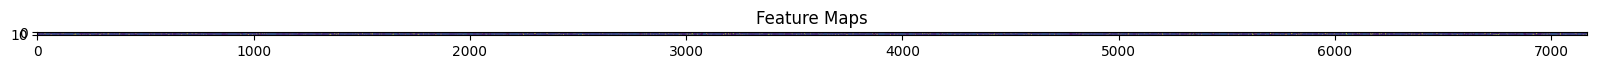

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect="auto")